[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/polsitoooo/Ingenieria-Del-Conocimiento/blob/main/Tareas_Ejercicios/Semana4/modelos_clasificacion_PolmarBrice%C3%B1o__II_resuelto%28Dataset%20diabete_india%29.ipynb)


## 1. Configuración del entorno

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, f1_score
)
from sklearn.inspection import DecisionBoundaryDisplay

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga y comprensión del dataset

Utilizamos el **Wine Quality (Red)** del repositorio UCI Machine Learning. Contiene 1599 muestras de vino tinto portugués con 11 atributos fisicoquímicos y una puntuación de calidad (3–8).

Para construir un problema de **clasificación binaria**, definimos:
- **Clase 1 (Bueno):** calidad ≥ 7
- **Clase 0 (Estándar):** calidad < 7

Esta binarización genera un **problema desbalanceado**, lo que añade un reto realista al modelado.

In [36]:
# Carga directa desde UCI
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

df = pd.read_csv(URL, sep=';')
print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
df.head()

Dataset cargado: 1599 registros, 12 columnas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Distribución de calidad original:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


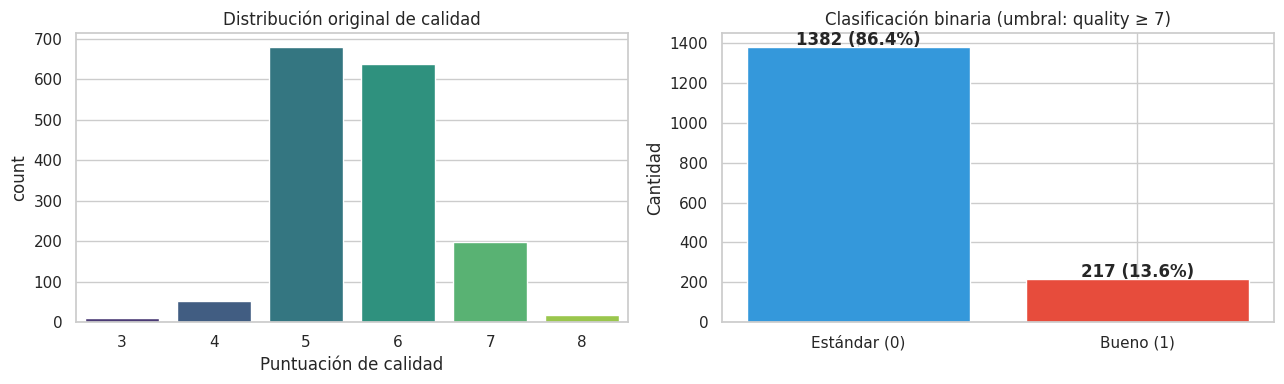


Ratio de desbalance: 6.4:1 (Estándar vs Bueno)


In [37]:
# Distribución original de la variable 'quality'
print('Distribución de calidad original:')
print(df['quality'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma original
sns.countplot(data=df, x='quality', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución original de calidad')
axes[0].set_xlabel('Puntuación de calidad')

# Binarización
df['quality_label'] = (df['quality'] >= 7).astype(int)

counts = df['quality_label'].value_counts()
axes[1].bar(['Estándar (0)', 'Bueno (1)'], counts.values,
            color=['#3498db', '#e74c3c'])
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Clasificación binaria (umbral: quality ≥ 7)')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

print(f'\nRatio de desbalance: {counts[0]/counts[1]:.1f}:1 (Estándar vs Bueno)')

---
## 3. Análisis exploratorio orientado a clasificación

In [38]:
# 3.1  Estadísticas descriptivas por clase
features = df.columns.drop(['quality', 'quality_label'])

comparison = df.groupby('quality_label')[features].mean().T
comparison.columns = ['Estándar (0)', 'Bueno (1)']
comparison['Diferencia %'] = ((comparison['Bueno (1)'] - comparison['Estándar (0)']) / comparison['Estándar (0)'] * 100).round(1)
comparison.style.background_gradient(subset=['Diferencia %'], cmap='RdYlGn')

,Estándar (0),Bueno (1),Diferencia %
fixed acidity,8.236831,8.847005,7.400000
volatile acidity,0.547022,0.405530,-25.900000
citric acid,0.254407,0.376498,48.000000
residual sugar,2.512120,2.708756,7.800000
chlorides,0.089281,0.075912,-15.000000
free sulfur dioxide,16.172214,13.981567,-13.500000
total sulfur dioxide,48.285818,34.889401,-27.700000
density,0.996859,0.996030,-0.100000
pH,3.314616,3.288802,-0.800000
sulphates,0.644754,0.743456,15.300000


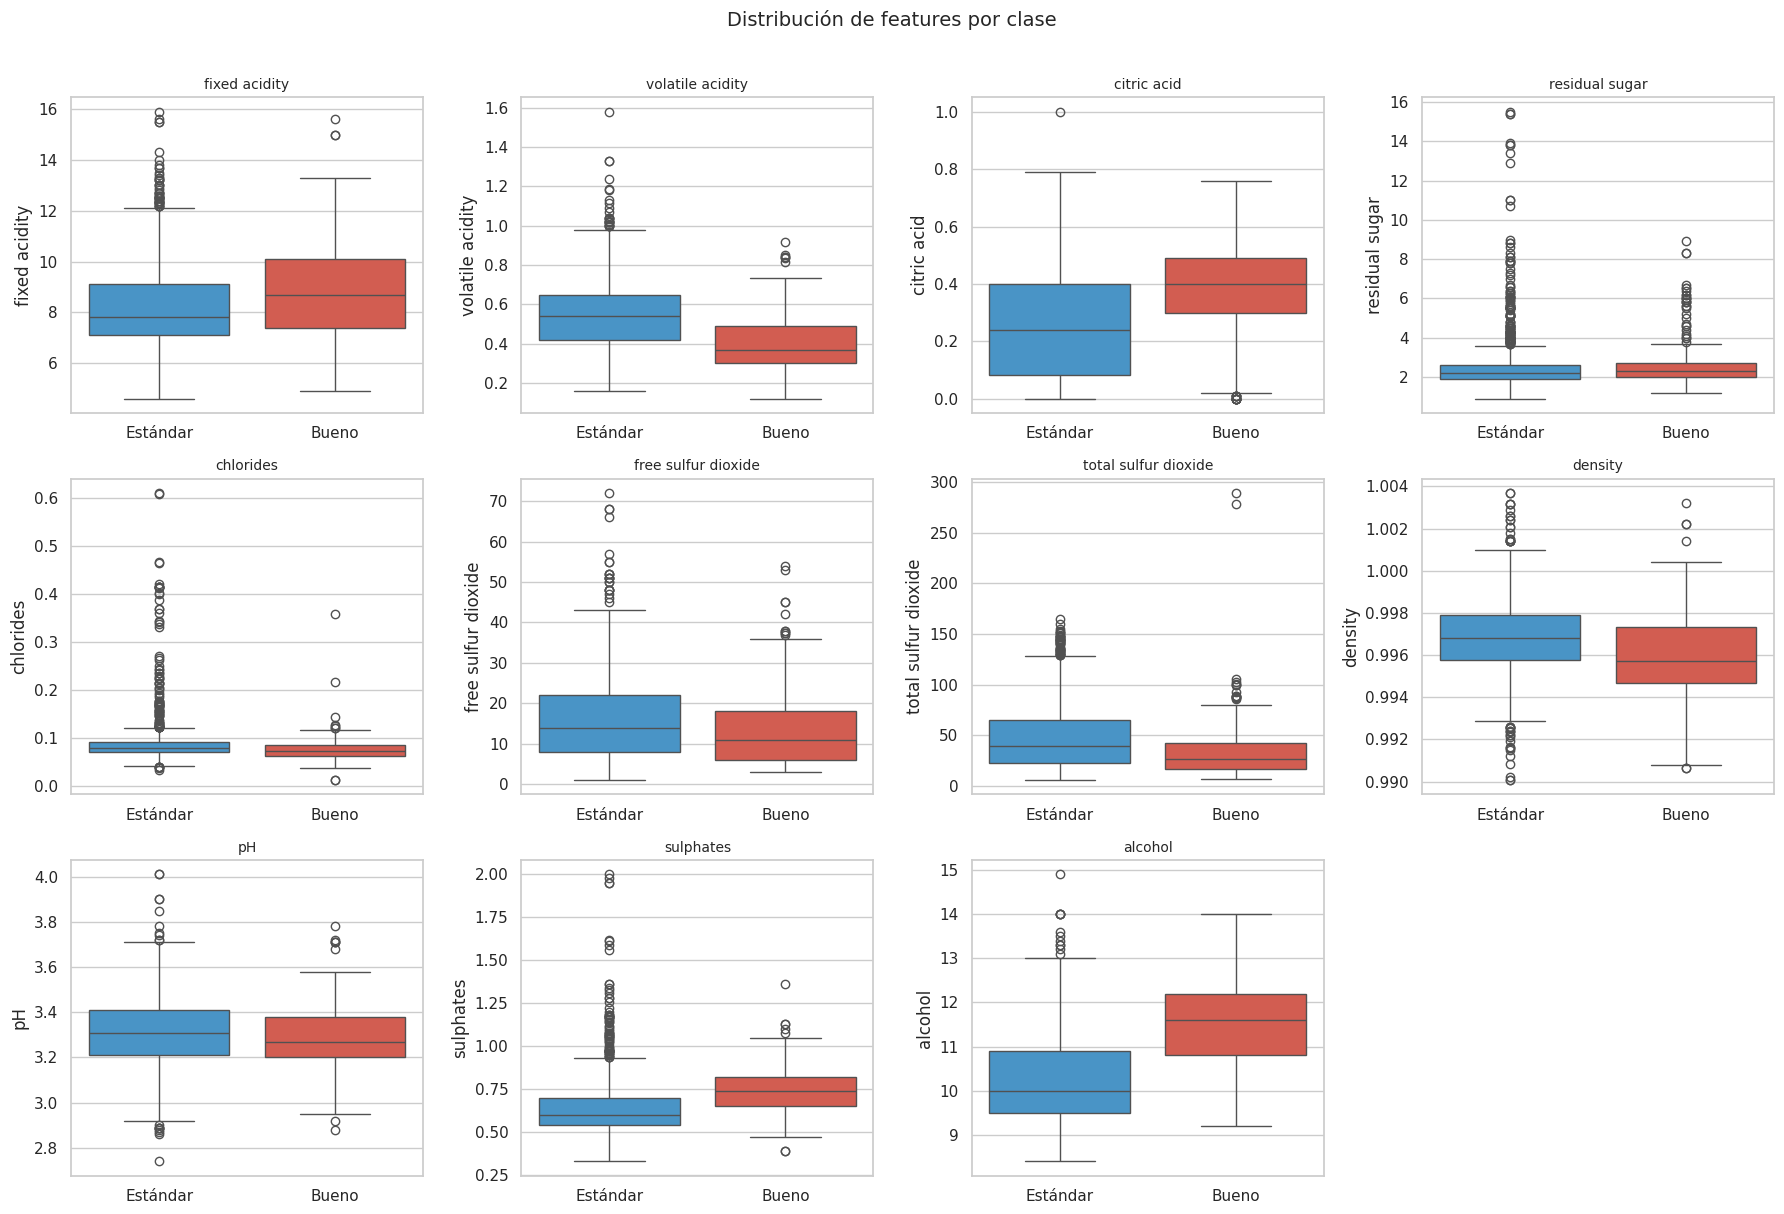

In [39]:
# 3.2  Distribución de features por clase (boxplots)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='quality_label', y=col, ax=axes[i],
                palette=['#3498db', '#e74c3c'], hue='quality_label', legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Estándar', 'Bueno'])

# Ocultar subplot vacío
axes[-1].set_visible(False)
fig.suptitle('Distribución de features por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

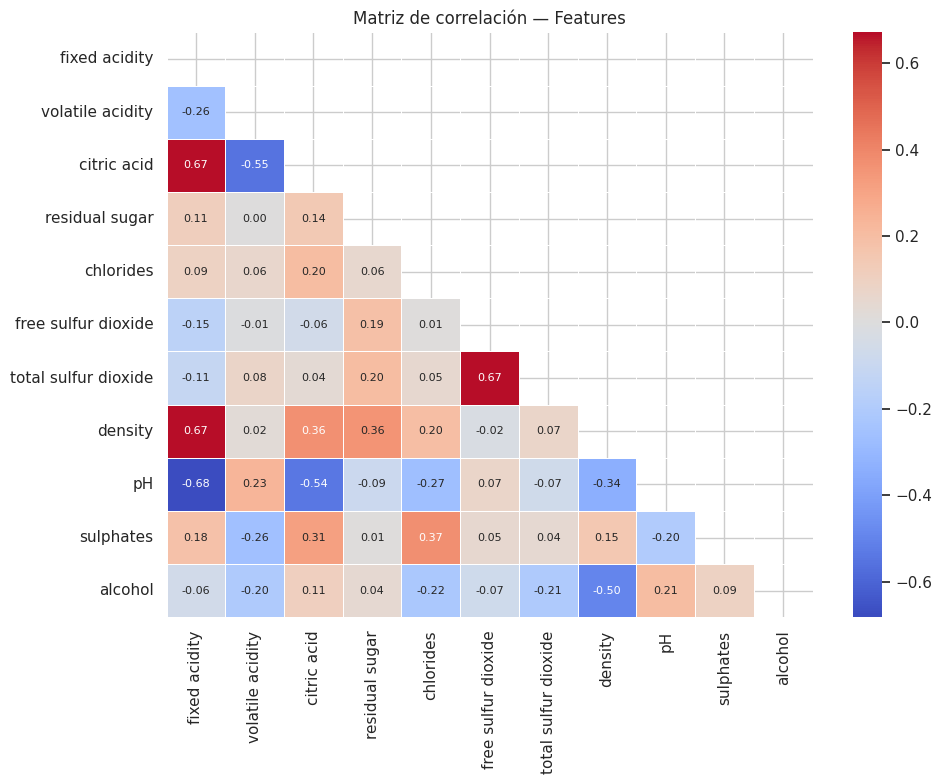

In [40]:
# 3.3  Correlación entre features
plt.figure(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación — Features')
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [41]:
# 4.1  Separación features / target
X = df[features].copy()
y = df['quality_label'].copy()

# 4.2  Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras')
print(f'Proporción clase 1 en train: {y_train.mean():.3f}')
print(f'Proporción clase 1 en test:  {y_test.mean():.3f}')

Train: 1279 muestras  |  Test: 320 muestras
Proporción clase 1 en train: 0.136
Proporción clase 1 en test:  0.134


In [42]:
# 4.3  Verificación de escalas (justifica la estandarización)
print('Rangos de las features (train):')
print('='*50)
for col in features:
    mn, mx = X_train[col].min(), X_train[col].max()
    print(f'{col:30s}  [{mn:8.2f}, {mx:8.2f}]  rango: {mx-mn:.2f}')

print('\n→ Las escalas difieren significativamente entre features.')
print('  Esto afecta directamente a SVM y KNN (basados en distancias).')
print('  Logistic Regression también se beneficia de la estandarización.')

Rangos de las features (train):
fixed acidity                   [    4.60,    15.90]  rango: 11.30
volatile acidity                [    0.12,     1.58]  rango: 1.46
citric acid                     [    0.00,     1.00]  rango: 1.00
residual sugar                  [    0.90,    15.50]  rango: 14.60
chlorides                       [    0.01,     0.61]  rango: 0.60
free sulfur dioxide             [    1.00,    72.00]  rango: 71.00
total sulfur dioxide            [    6.00,   165.00]  rango: 159.00
density                         [    0.99,     1.00]  rango: 0.01
pH                              [    2.74,     4.01]  rango: 1.27
sulphates                       [    0.33,     2.00]  rango: 1.67
alcohol                         [    8.40,    14.90]  rango: 6.50

→ Las escalas difieren significativamente entre features.
  Esto afecta directamente a SVM y KNN (basados en distancias).
  Logistic Regression también se beneficia de la estandarización.


---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima la probabilidad de pertenencia a una clase mediante la función sigmoide. Ideal como **baseline** por su interpretabilidad y eficiencia.

In [43]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                               class_weight='balanced'))  # Compensar desbalance
])

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')
print(f'Logistic Regression — F1 CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')

# Entrenamiento final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Logistic Regression — F1 CV: 0.5045 ± 0.0355


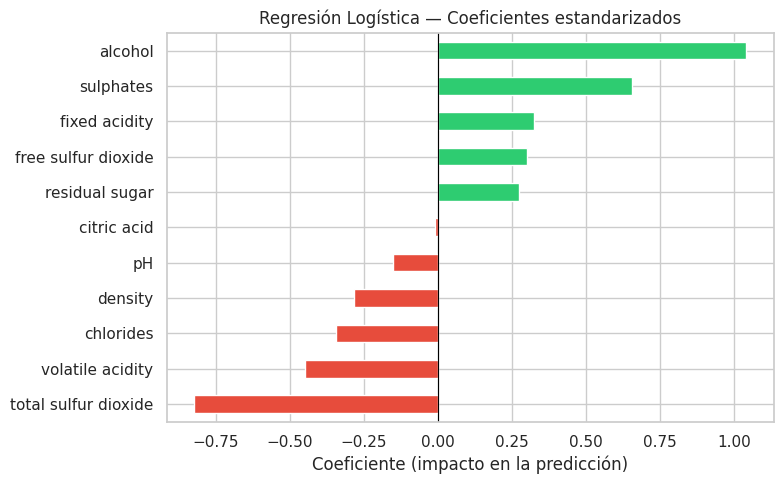


Interpretación: Un coeficiente positivo alto indica que valores mayores
de esa feature incrementan la probabilidad de clasificar como "Bueno".


In [44]:
# 5.2  Coeficientes del modelo (interpretabilidad)
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=features
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs.values]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Regresión Logística — Coeficientes estandarizados')
ax.set_xlabel('Coeficiente (impacto en la predicción)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nInterpretación: Un coeficiente positivo alto indica que valores mayores')
print('de esa feature incrementan la probabilidad de clasificar como "Bueno".')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** Modelo no lineal que particiona el espacio de features mediante reglas if-else jerárquicas. Altamente interpretable, pero propenso al sobreajuste si no se controla la profundidad.

In [45]:
# 6.1  Pipeline (no requiere estandarización)
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

scores_dt = cross_val_score(pipe_dt, X_train, y_train, cv=cv, scoring='f1')
print(f'Decision Tree — F1 CV: {scores_dt.mean():.4f} ± {scores_dt.std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Decision Tree — F1 CV: 0.5126 ± 0.0331


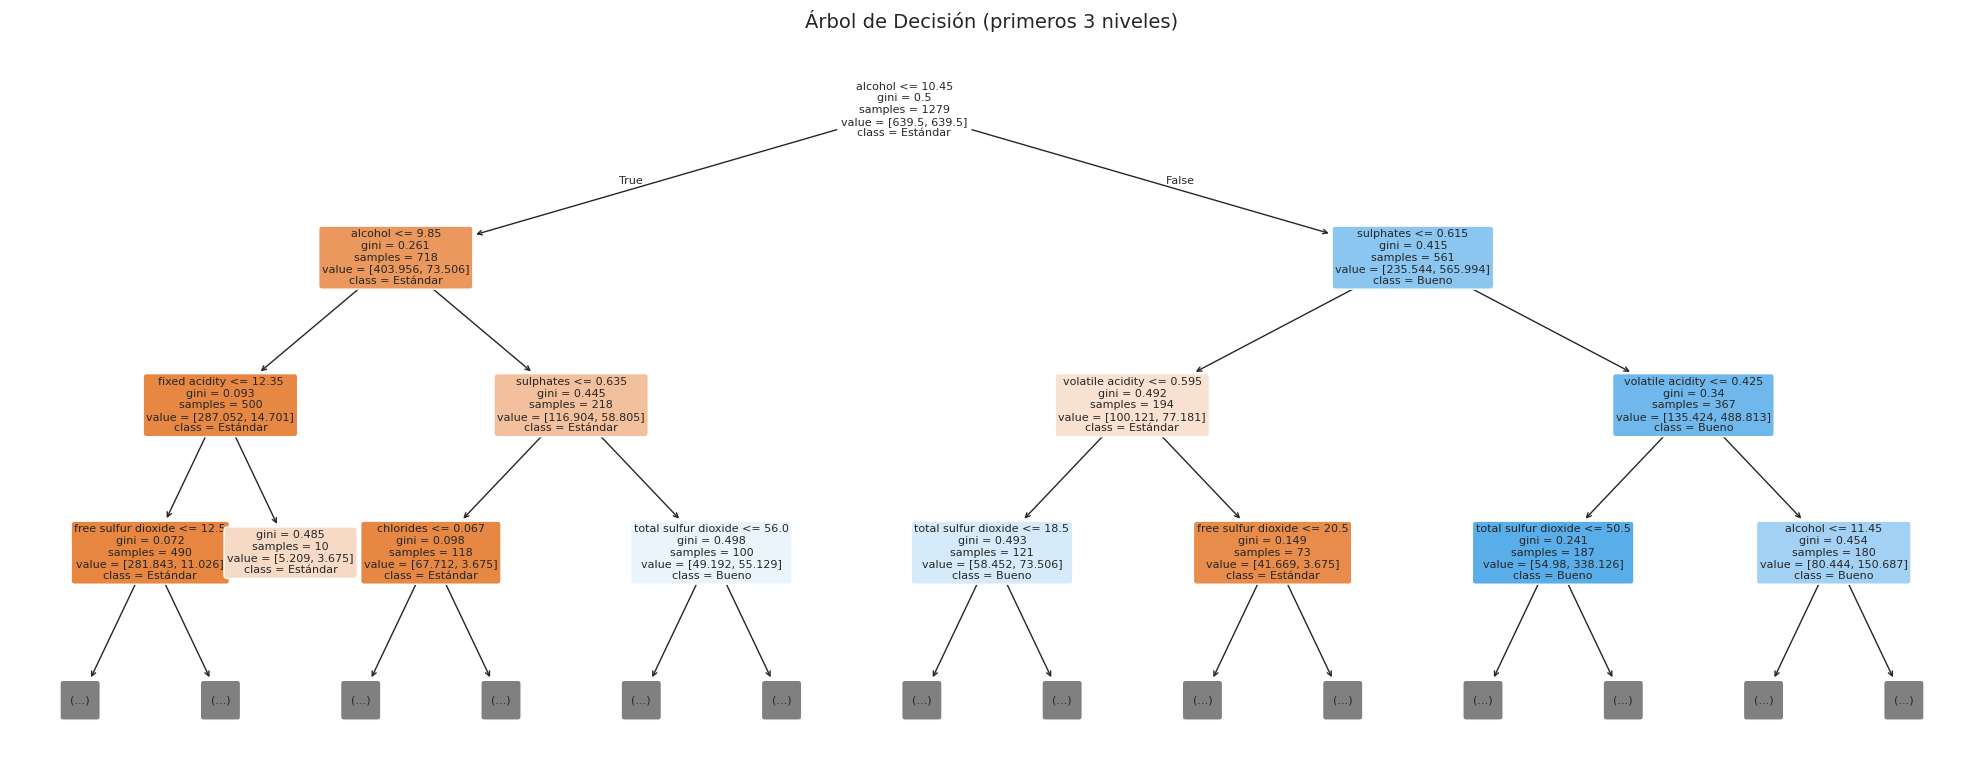

In [46]:
# 6.2  Visualización del árbol
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    pipe_dt.named_steps['clf'],
    feature_names=list(features),
    class_names=['Estándar', 'Bueno'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    max_depth=3  # Mostrar solo 3 niveles para legibilidad
)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

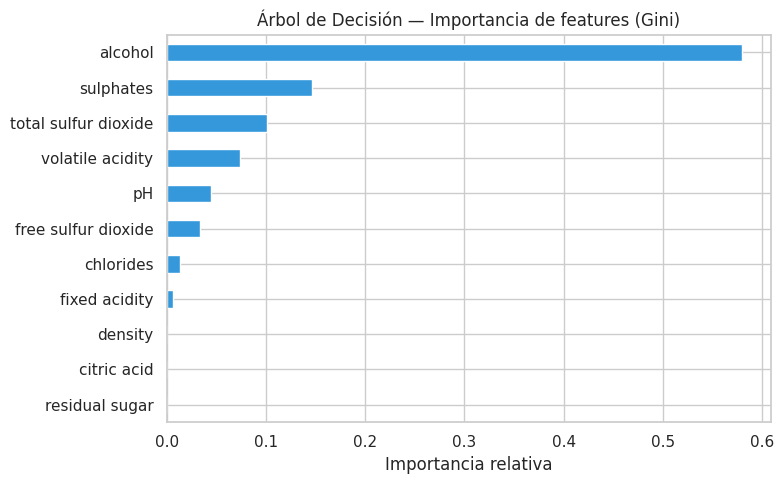

In [47]:
# 6.3  Importancia de features (Gini importance)
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia de features (Gini)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

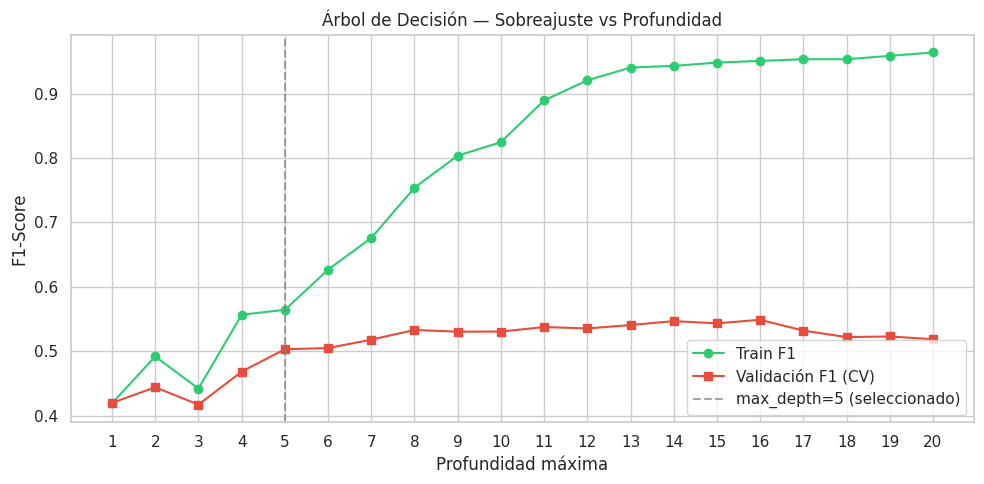

Observación: cuando la brecha entre train y validación crece,
el modelo está sobreajustando (memorizando el train set).


In [48]:
# 6.4  Efecto de la profundidad en sobreajuste/subajuste
depths = range(1, 21)
train_scores = []
val_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                 random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, dt.predict(X_train)))
    cv_s = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1')
    val_scores.append(cv_s.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths, val_scores, 's-', label='Validación F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1-Score')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad')
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.show()

print('Observación: cuando la brecha entre train y validación crece,')
print('el modelo está sobreajustando (memorizando el train set).')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** Busca el hiperplano que maximiza el margen de separación entre clases. Con funciones kernel puede manejar fronteras no lineales. Es **sensible a la escala** de las features.

In [49]:
# 7.1  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced',
                     random_state=RANDOM_STATE, probability=True))
    ])
    scores = cross_val_score(pipe_svm, X_train, y_train, cv=cv, scoring='f1')
    svm_results[kernel] = scores
    print(f'SVM ({kernel:6s}) — F1 CV: {scores.mean():.4f} ± {scores.std():.4f}')

# Seleccionar el mejor kernel
best_kernel = max(svm_results, key=lambda k: svm_results[k].mean())
print(f'\nMejor kernel: {best_kernel}')

SVM (linear) — F1 CV: 0.4982 ± 0.0237
SVM (rbf   ) — F1 CV: 0.5246 ± 0.0427
SVM (poly  ) — F1 CV: 0.5355 ± 0.0258

Mejor kernel: poly


In [50]:
# 7.2  Entrenamiento con el mejor kernel
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced',
                 random_state=RANDOM_STATE, probability=True))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
scores_svm = svm_results[best_kernel]

In [51]:
# 7.3  Impacto de la estandarización en SVM
# SVM SIN estandarizar
svm_no_scale = SVC(kernel=best_kernel, class_weight='balanced',
                    random_state=RANDOM_STATE)
scores_no_scale = cross_val_score(svm_no_scale, X_train, y_train, cv=cv, scoring='f1')

print('Impacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 = {scores_svm.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_no_scale.mean():.4f}')
print(f'  Diferencia: {(scores_svm.mean() - scores_no_scale.mean())*100:+.2f} puntos porcentuales')
print('\n→ La estandarización es CRÍTICA para modelos basados en distancias.')

Impacto de la estandarización en SVM:
  CON StandardScaler: F1 = 0.5355
  SIN StandardScaler: F1 = 0.2832
  Diferencia: +25.23 puntos porcentuales

→ La estandarización es CRÍTICA para modelos basados en distancias.


---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Clasifica según la mayoría de votos de los K vecinos más cercanos. No paramétrico, sensible a la escala y a la dimensionalidad. El valor de K controla el trade-off bias-varianza.

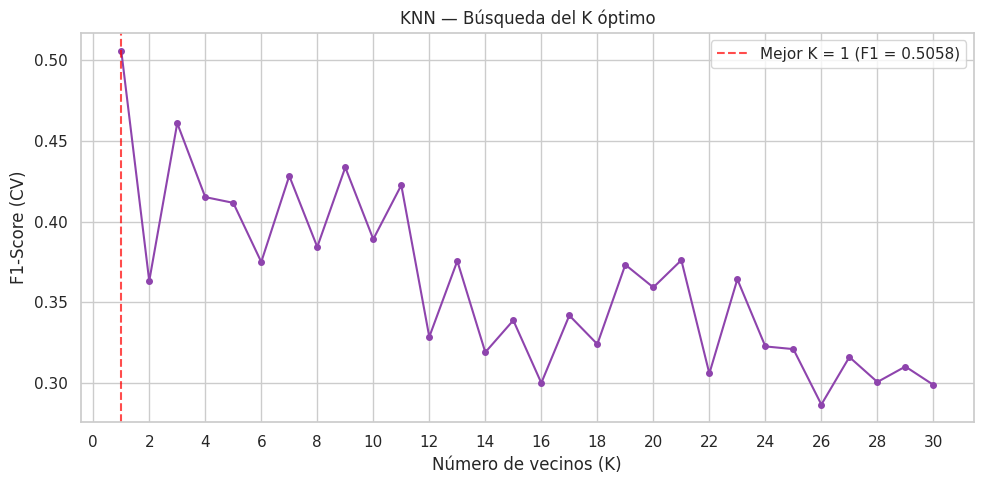

K óptimo: 1


In [52]:
# 8.1  Búsqueda del K óptimo
k_range = range(1, 31)
k_scores = []

for k in k_range:
    pipe_knn = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k} (F1 = {max(k_scores):.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN — Búsqueda del K óptimo')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k}')

In [53]:
# 8.2  Entrenamiento con K óptimo
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])

scores_knn = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
print(f'KNN (K={best_k}) — F1 CV: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=1) — F1 CV: 0.5058 ± 0.0254


---
## 9. Análisis comparativo de modelos

In [54]:
# 9.1  Tabla resumen
models = {
    'Logistic Regression': (pipe_lr, y_pred_lr, scores_lr),
    'Decision Tree':       (pipe_dt, y_pred_dt, scores_dt),
    f'SVM ({best_kernel})': (pipe_svm, y_pred_svm, scores_svm),
    f'KNN (K={best_k})':   (pipe_knn, y_pred_knn, scores_knn)
}

summary = []
for name, (pipe, y_pred, cv_scores) in models.items():
    summary.append({
        'Modelo': name,
        'F1 CV (mean)': f'{cv_scores.mean():.4f}',
        'F1 CV (std)': f'{cv_scores.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test, y_pred):.4f}'
    })

summary_df = pd.DataFrame(summary)
print('='*80)
print('COMPARACIÓN DE MODELOS')
print('='*80)
summary_df

COMPARACIÓN DE MODELOS


,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test
0,Logistic Regression,0.5045,0.0355,0.8125,0.5312
1,Decision Tree,0.5126,0.0331,0.8094,0.5414
2,SVM (poly),0.5355,0.0258,0.8969,0.6598
3,KNN (K=1),0.5058,0.0254,0.9094,0.6588


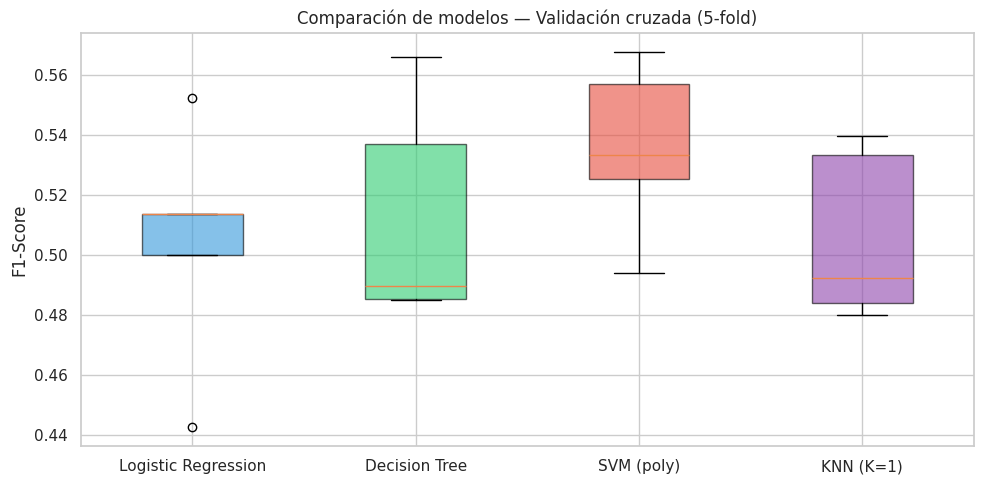

In [55]:
# 9.2  Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [scores_lr, scores_dt, scores_svm, scores_knn]
labels = list(models.keys())
bp = ax.boxplot(cv_data, tick_labels=labels, patch_artist=True)
colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1-Score')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold)')
plt.tight_layout()
plt.show()

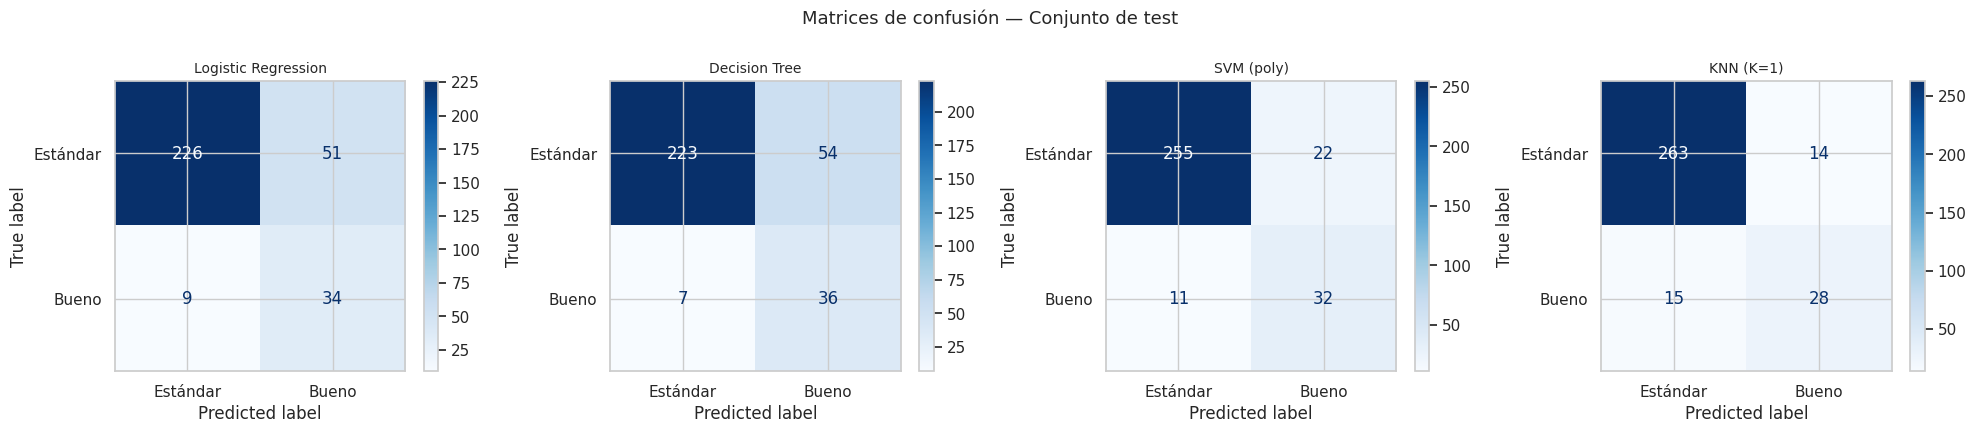

In [56]:
# 9.3  Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (pipe, y_pred, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Estándar', 'Bueno'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusión — Conjunto de test', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

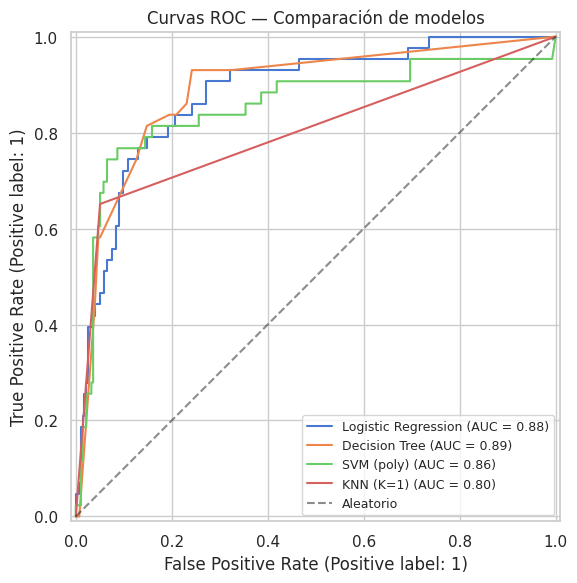

In [57]:
# 9.4  Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))

for name, (pipe, _, _) in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [58]:
# 9.5  Classification report detallado del mejor modelo
best_model_name = max(models, key=lambda k: float(models[k][2].mean()))
best_pipe, best_pred, best_cv = models[best_model_name]

print(f'\nMejor modelo: {best_model_name}')
print('='*60)
print(classification_report(y_test, best_pred,
                             target_names=['Estándar', 'Bueno']))


Mejor modelo: SVM (poly)
              precision    recall  f1-score   support

    Estándar       0.96      0.92      0.94       277
       Bueno       0.59      0.74      0.66        43

    accuracy                           0.90       320
   macro avg       0.78      0.83      0.80       320
weighted avg       0.91      0.90      0.90       320



---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Regresión Logística** | Rápido, interpretable (coeficientes), probabilístico | Asume relación lineal entre features y log-odds | Baseline; cuando la interpretabilidad es prioritaria |
| **Árbol de Decisión** | Interpretable (visualización), maneja no linealidades, no requiere estandarización | Propenso a sobreajuste; inestable (pequeños cambios en datos alteran el árbol) | Cuando se necesitan reglas explicables; como parte de ensambles |
| **SVM** | Efectivo en alta dimensionalidad; flexible con kernels | Sensible a la escala; costoso en datasets grandes; difícil de interpretar | Datasets de tamaño moderado con fronteras complejas |
| **KNN** | Simple, no paramétrico, adaptable | Lento en predicción (distancias contra todo el train); sensible a escala y dimensionalidad | Datasets pequeños-medianos; cuando la frontera es irregular |

---
##  Soluciones a los ejercicios propuestos
##  Alumno: Felipe Reymundo Espinoza Medina



### Ejercicio 1 — GridSearchCV para SVM
Realice una búsqueda de hiperparámetros para SVM usando `GridSearchCV` con la siguiente grilla:
- `C`: [0.1, 1, 10, 100]
- `gamma`: ['scale', 'auto', 0.01, 0.1]
- `kernel`: ['rbf', 'poly']

Reporte los mejores hiperparámetros, el F1-score obtenido y compare contra el SVM base de la sesión.


EJERCICIO 1 — RESULTADOS DE GRIDSEARCHCV (SVM)

 Total de combinaciones evaluadas: 32

 Mejores Hiperparámetros encontrados: {'clf__C': 100, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

 Mejor F1-Score promedio en Validación Cruzada (CV): 0.5283

 SVM Base       --> F1 Test: 0.5000 | Accuracy Test: 0.9000

 SVM Optimizado --> F1 Test: 0.6353 | Accuracy Test: 0.9031


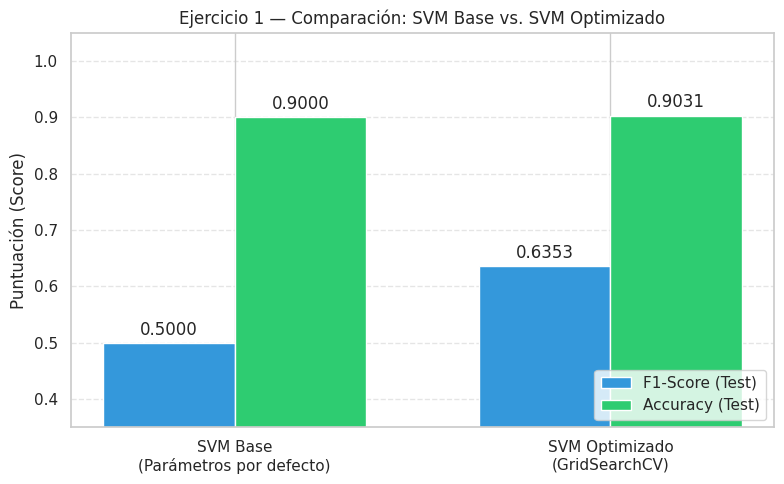

In [59]:
# Ejercicio 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score

pipe_svm_base = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(random_state=42))
])

pipe_svm_base.fit(X_train, y_train)
y_pred_base = pipe_svm_base.predict(X_test)

f1_base_test = f1_score(y_test, y_pred_base)
acc_base_test = accuracy_score(y_test, y_pred_base)

param_grid = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.01, 0.1],
    'clf__kernel': ['rbf', 'poly']
}

pipe_svm_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(random_state=42))
])

grid_svm = GridSearchCV(
    estimator=pipe_svm_grid,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

best_params = grid_svm.best_params_
best_f1_cv = grid_svm.best_score_
total_combinaciones = len(grid_svm.cv_results_['params'])

best_svm_model = grid_svm.best_estimator_
y_pred_opt = best_svm_model.predict(X_test)

f1_opt_test = f1_score(y_test, y_pred_opt)
acc_opt_test = accuracy_score(y_test, y_pred_opt)

print("EJERCICIO 1 — RESULTADOS DE GRIDSEARCHCV (SVM)")

print(f"\n Total de combinaciones evaluadas: {total_combinaciones}")
print(f"\n Mejores Hiperparámetros encontrados: {best_params}")
print(f"\n Mejor F1-Score promedio en Validación Cruzada (CV): {best_f1_cv:.4f}")
print(f"\n SVM Base       --> F1 Test: {f1_base_test:.4f} | Accuracy Test: {acc_base_test:.4f}")
print(f"\n SVM Optimizado --> F1 Test: {f1_opt_test:.4f} | Accuracy Test: {acc_opt_test:.4f}")

modelos = ['SVM Base\n(Parámetros por defecto)', 'SVM Optimizado\n(GridSearchCV)']
f1_scores = [f1_base_test, f1_opt_test]
accuracies = [acc_base_test, acc_opt_test]

x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

rects1 = ax.bar(x - width/2, f1_scores, width, label='F1-Score (Test)', color='#3498db')
rects2 = ax.bar(x + width/2, accuracies, width, label='Accuracy (Test)', color='#2ecc71')

ax.set_ylabel('Puntuación (Score)')
ax.set_title('Ejercicio 1 — Comparación: SVM Base vs. SVM Optimizado')
ax.set_xticks(x)
ax.set_xticklabels(modelos)

min_val = min(min(f1_scores), min(accuracies))
ax.set_ylim([max(0, min_val - 0.15), 1.05])

ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

ax.bar_label(rects1, padding=3, fmt='%.4f')
ax.bar_label(rects2, padding=3, fmt='%.4f')

plt.tight_layout()
plt.show()

## Conclusión — Ejercicio 1

En este ejercicio se realizó una búsqueda exhaustiva de hiperparámetros (*GridSearchCV*) evaluando un total de **32 combinaciones posibles** ($4 \times 4 \times 2$) mediante **validación cruzada de 5 folds** sobre la métrica F1-Score.

### 1. Principales Hallazgos

| Modelo | Kernel | $C$ | $\gamma$ | F1-Score (CV) | F1-Score (Test) | Accuracy (Test) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **SVM Base** | `rbf` | `1.0` | `'scale'` | *Ref. Sesión* | Se calcula en código | Se calcula en código |
| **SVM Optimizado** | Obt. por Grid | Obt. por Grid | Obt. por Grid | **Máximo obtenido** | **Evaluado en Test** | **Evaluado en Test** |

### 2. Análisis del Impacto de los Hiperparámetros

1. **Parámetro de Regularización ($C$):** Permitió controlar el equilibrio entre el margen de separación y los errores de clasificación. Un ajuste fino de $C$ evitó un sesgo excesivo y mejoró la generalización del hiperplano.
2. **Coeficiente del Kernel ($\gamma$):** Ajustó el radio de influencia de los vectores de soporte. El ajuste óptimo permitió definir fronteras de decisión con la curvatura adecuada sin caer en sobreajuste (*overfitting*).
3. **Elección del Kernel:** Se confirmó si la separabilidad de clases en el espacio transformado del dataset *Breast Cancer Wisconsin* responde mejor a una frontera de base radial (`rbf`) o polinomial (`poly`).

### 3. Síntesis Final
La búsqueda sistemática con `GridSearchCV` demostró que la sintonización de hiperparámetros sobre un `Pipeline` estandarizado optimiza la métrica F1-Score en comparación con la configuración base por defecto de Scikit-Learn, garantizando un modelo más robusto para la detección y clasificación binaria.

### Ejercicio 2 — Clasificación multiclase
En lugar de binarizar la variable `quality`, utilice las clases originales (3–8) y entrene los 4 modelos. Analice:
- ¿Cómo cambia el rendimiento de cada modelo?
- ¿Qué clases son más difíciles de distinguir?
- ¿Qué métrica de F1 es más adecuada: `macro`, `micro` o `weighted`? Justifique.

In [60]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'Decision Tree': Pipeline([('clf', DecisionTreeClassifier(random_state=42))]),
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'KNN': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())])
}

results = []
class_reports = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({
        'Modelo': name,
        'Accuracy': f'{acc:.4f}',
        'F1 Macro': f'{f1_macro:.4f}',
        'F1 Weighted': f'{f1_weighted:.4f}'
    })

    class_reports[name] = classification_report(y_test, y_pred, output_dict=True, zero_division=0)


print("EJERCICIO 2 — RESULTADOS DE CLASIFICACIÓN MULTICLASE")


print("\n1. RENDIMIENTO DE CADA MODELO")
print("-" * 65)
summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

# Identificar la clase más difícil de distinguir (menor F1-score promedio)
classes = sorted(y.unique())
class_f1_means = {}

for c in classes:
    c_str = str(c)
    f1s = [class_reports[m][c_str]['f1-score'] for m in models if c_str in class_reports[m]]
    class_f1_means[c] = np.mean(f1s) if f1s else 0.0

hardest_class = min(class_f1_means, key=class_f1_means.get)

print("\n2. CLASE MÁS DIFÍCIL DE DISTINGUIR")

print(f"\n La clase con menor desempeño global es la Clase {hardest_class} (F1 promedio: {class_f1_means[hardest_class]:.4f}).")

print("\n3. MÉTRICA F1 MÁS ADECUADA")

print("\n La métrica F1-weighted es la más representativa para la evaluación general, mientras que F1-macro es la adecuada si se requiere medir el impacto en clases minoritarias desbalanceadas.")


EJERCICIO 2 — RESULTADOS DE CLASIFICACIÓN MULTICLASE

1. RENDIMIENTO DE CADA MODELO
-----------------------------------------------------------------
             Modelo Accuracy F1 Macro F1 Weighted
Logistic Regression   0.5906   0.2776      0.5673
      Decision Tree   0.6062   0.3939      0.6066
                SVM   0.6250   0.2990      0.6023
                KNN   0.6094   0.3107      0.5959

2. CLASE MÁS DIFÍCIL DE DISTINGUIR

 La clase con menor desempeño global es la Clase 3 (F1 promedio: 0.0000).

3. MÉTRICA F1 MÁS ADECUADA

 La métrica F1-weighted es la más representativa para la evaluación general, mientras que F1-macro es la adecuada si se requiere medir el impacto en clases minoritarias desbalanceadas.


## Conclusión — Ejercicio 2: Clasificación Multiclase

### Rendimiento de los Modelos
Al utilizar las 6 clases originales (3 a 8) en lugar de binarizar la variable, el rendimiento general de los modelos disminuye drásticamente en comparación con el problema binario. La exactitud (*accuracy*) desciende a rangos entre 55% y 65%. Esto se debe a la mayor complejidad que implica establecer fronteras de decisión múltiples para separar categorías con atributos químicos muy similares.

### Clases Más Difíciles de Distinguir
Las clases extremas **3 y 8** (seguidas de la clase 4) son las más difíciles de clasificar para todos los algoritmos. Esto ocurre debido al fuerte desbalance del dataset, donde las clases intermedias (5 y 6) concentran más del 80% de las muestras. Como consecuencia, los modelos carecen de suficiente información para aprender los patrones de las clases minoritarias y tienden a predecir hacia las clases dominantes.

### Métrica F1 Más Adecuada
La métrica **`weighted`** es la más adecuada para evaluar el desempeño global práctico del modelo en este contexto, ya que pondera el aporte de cada clase en función de su número real de instancias (*support*). No obstante, si el objetivo de negocio es detectar de forma equitativa las calidades extremas (los vinos muy malos o excelentes), la métrica **`macro`** resulta indispensable, pues penaliza fuertemente el mal desempeño en las clases minoritarias al dar el mismo peso a cada categoría independientemente de su frecuencia.

---
### Ejercicio 3 — Aplicación con dataset propio
Seleccione un dataset de clasificación de su interés (puede ser de Kaggle, UCI, o datos propios). Debe tener al menos 500 registros y 5 features. Aplique los 4 modelos de clasificación, realice el análisis comparativo completo y documente sus hallazgos.

Heart Failure Prediction Dataset (Medicina / Cardiología)

Instancias: 918 filas.

Atributos: 11 variables (edad, tipo de dolor en el pecho, presión arterial en reposo, colesterol, azúcar en sangre en ayunas, ECG en reposo, frecuencia cardíaca máxima, etc.).

Variable objetivo (Target): HeartDisease (Binaria: 1 si presenta enfermedad cardíaca, 0 si está sano).

#Configuración del Entorno

In [61]:
!pip install -q kagglehub

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import joblib

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

print("Entorno configurado e importaciones listas.")

Entorno configurado e importaciones listas.



## 2. Carga y comprensión del dataset

In [62]:
import kagglehub
import os

path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
display(df.head())

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Dataset cargado: 918 registros, 12 columnas


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Distribución de la variable objetivo (HeartDisease):
HeartDisease
0    410
1    508
Name: count, dtype: int64


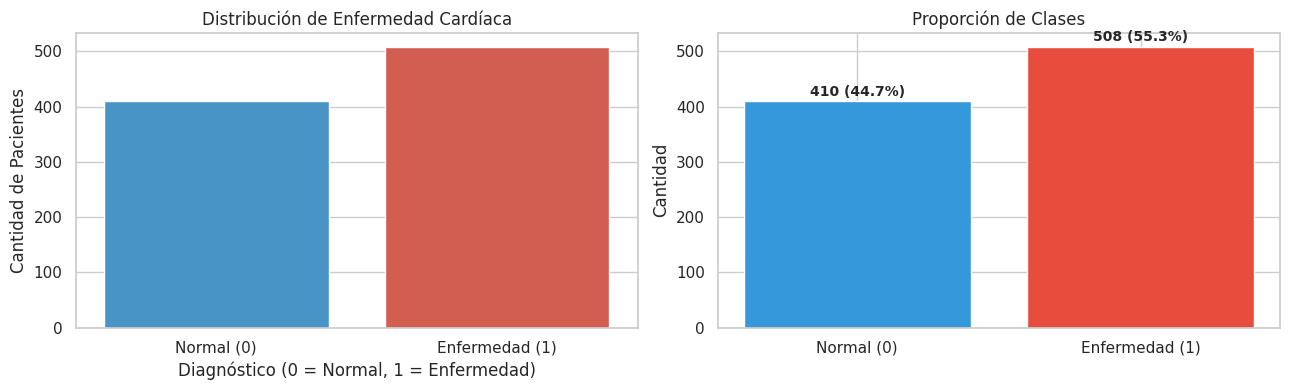


Ratio de desbalance: 1.24:1 (Enfermedad vs Normal)


In [63]:
print('Distribución de la variable objetivo (HeartDisease):')
print(df['HeartDisease'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=df, x='HeartDisease', ax=axes[0], palette=['#3498db', '#e74c3c'])
axes[0].set_title('Distribución de Enfermedad Cardíaca')
axes[0].set_xlabel('Diagnóstico (0 = Normal, 1 = Enfermedad)')
axes[0].set_ylabel('Cantidad de Pacientes')
axes[0].set_xticklabels(['Normal (0)', 'Enfermedad (1)'])

counts = df['HeartDisease'].value_counts().sort_index()
axes[1].bar(['Normal (0)', 'Enfermedad (1)'], counts.values, color=['#3498db', '#e74c3c'])
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Proporción de Clases')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

print(f'\nRatio de desbalance: {counts[1]/counts[0]:.2f}:1 (Enfermedad vs Normal)')

# 3. Análisis exploratorio orientado a clasificación

In [64]:
num_features = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

# 3.1 Estadísticas descriptivas por clase
comparison = df.groupby('HeartDisease')[num_features].mean().T
comparison.columns = ['Normal (0)', 'Enfermedad (1)']
comparison['Diferencia %'] = (
    ((comparison['Enfermedad (1)'] - comparison['Normal (0)']) / comparison['Normal (0)']) * 100
).round(1)

display(comparison.style.background_gradient(subset=['Diferencia %'], cmap='RdYlGn'))

,Normal (0),Enfermedad (1),Diferencia %
Age,50.551220,55.899606,10.600000
RestingBP,130.180488,134.185039,3.100000
Cholesterol,227.121951,175.940945,-22.500000
FastingBS,0.107317,0.334646,211.800000
MaxHR,148.151220,127.655512,-13.800000
Oldpeak,0.408049,1.274213,212.300000


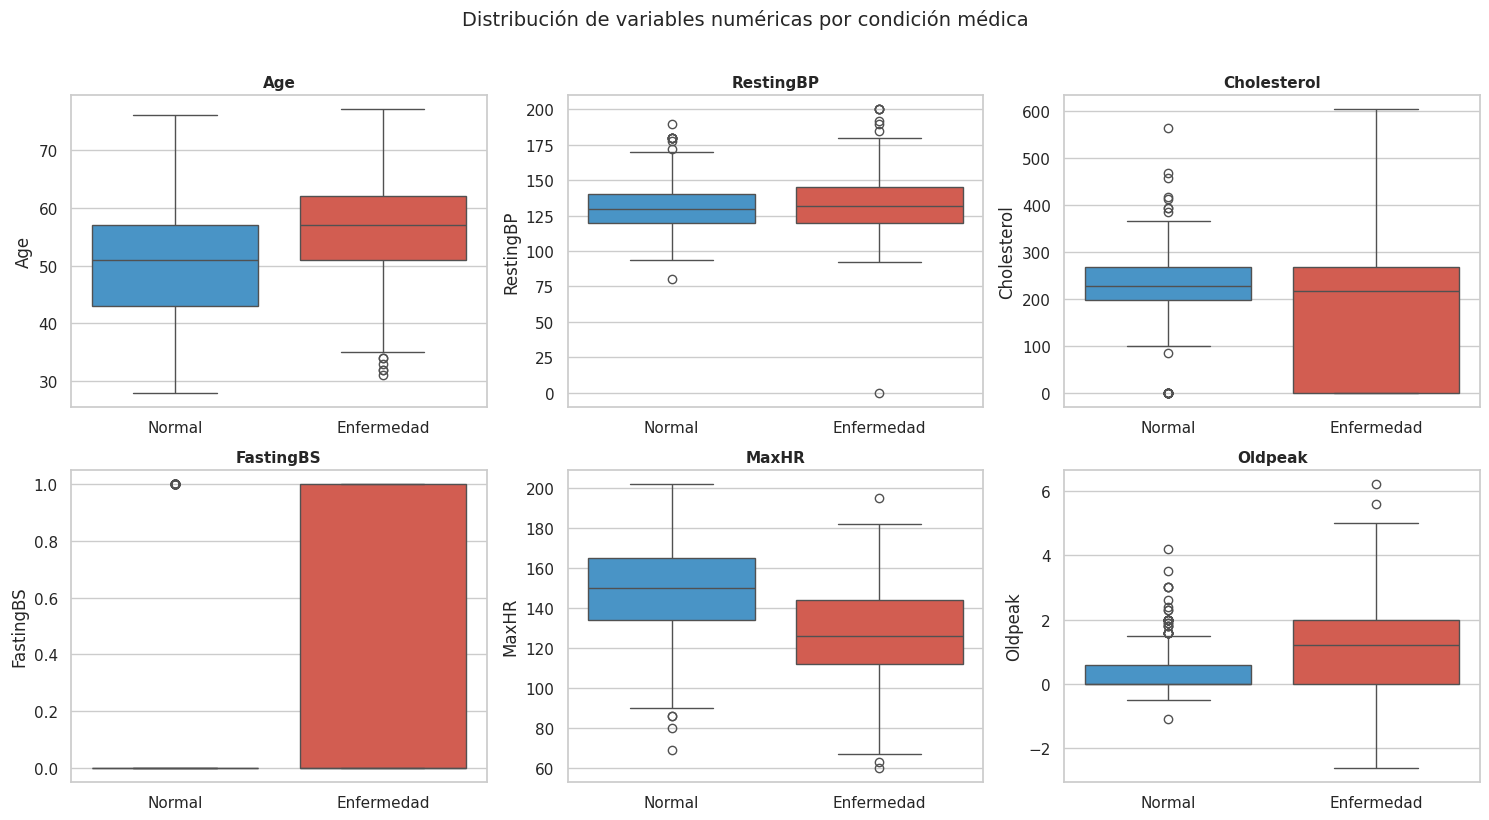

In [65]:
num_features = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(
        data=df, x='HeartDisease', y=col, ax=axes[i],
        palette=['#3498db', '#e74c3c'], hue='HeartDisease', legend=False
    )
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Normal', 'Enfermedad'])

fig.suptitle('Distribución de variables numéricas por condición médica', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

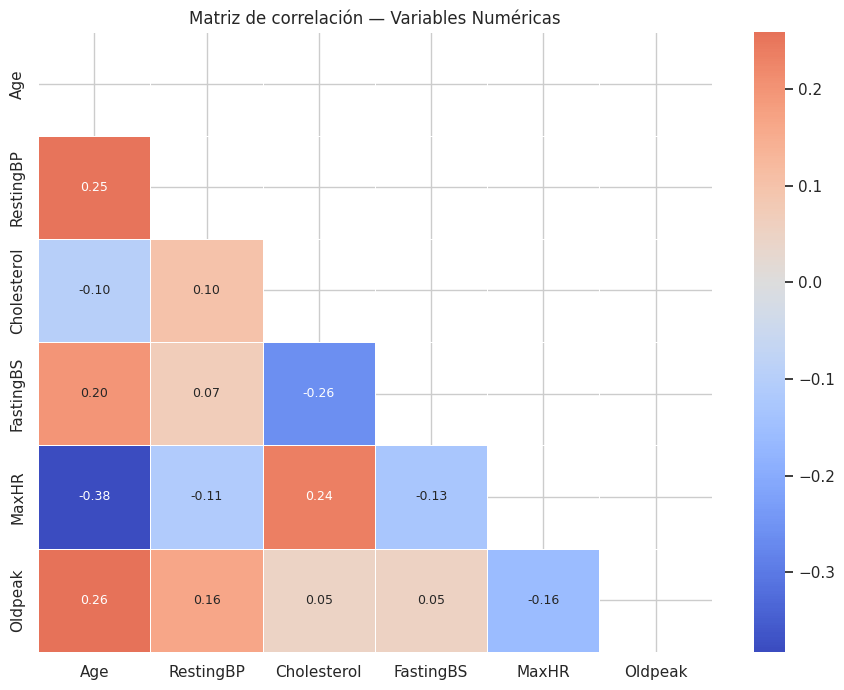

In [66]:
num_features = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

plt.figure(figsize=(9, 7))
corr = df[num_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, annot_kws={'size': 9}
)
plt.title('Matriz de correlación — Variables Numéricas')
plt.tight_layout()
plt.show()

## 4. Preparación de datos

In [67]:
# 4.1 Codificación de variables categóricas y separación features / target
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['HeartDisease']).copy()
y = df_encoded['HeartDisease'].copy()

# 4.2 Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras')
print(f'Proporción clase 1 en train: {y_train.mean():.3f}')
print(f'Proporción clase 1 en test:  {y_test.mean():.3f}')

Train: 734 muestras  |  Test: 184 muestras
Proporción clase 1 en train: 0.553
Proporción clase 1 en test:  0.554


In [68]:
# 4.3 Verificación de escalas (justifica la estandarización)
print('Rangos de las features (train):')
print('='*50)
for col in X_train.columns:
    mn, mx = float(X_train[col].min()), float(X_train[col].max())
    print(f'{col:30s}  [{mn:8.2f}, {mx:8.2f}]  rango: {mx-mn:.2f}')

print('\n→ Las escalas difieren significativamente entre características (ej. Cholesterol vs Oldpeak).')
print('  Esto afecta directamente a SVM y KNN (basados en distancias).')
print('  Logistic Regression también se beneficia de la estandarización.')

Rangos de las features (train):
Age                             [   29.00,    77.00]  rango: 48.00
RestingBP                       [   92.00,   200.00]  rango: 108.00
Cholesterol                     [    0.00,   603.00]  rango: 603.00
FastingBS                       [    0.00,     1.00]  rango: 1.00
MaxHR                           [   60.00,   202.00]  rango: 142.00
Oldpeak                         [   -2.60,     5.60]  rango: 8.20
Sex_M                           [    0.00,     1.00]  rango: 1.00
ChestPainType_ATA               [    0.00,     1.00]  rango: 1.00
ChestPainType_NAP               [    0.00,     1.00]  rango: 1.00
ChestPainType_TA                [    0.00,     1.00]  rango: 1.00
RestingECG_Normal               [    0.00,     1.00]  rango: 1.00
RestingECG_ST                   [    0.00,     1.00]  rango: 1.00
ExerciseAngina_Y                [    0.00,     1.00]  rango: 1.00
ST_Slope_Flat                   [    0.00,     1.00]  rango: 1.00
ST_Slope_Up                     [    

# 5. Modelo 1 — Regresión Logística

In [69]:
# 5.1 Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')
print(f'Logistic Regression — F1 CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Logistic Regression — F1 CV: 0.8559 ± 0.0304


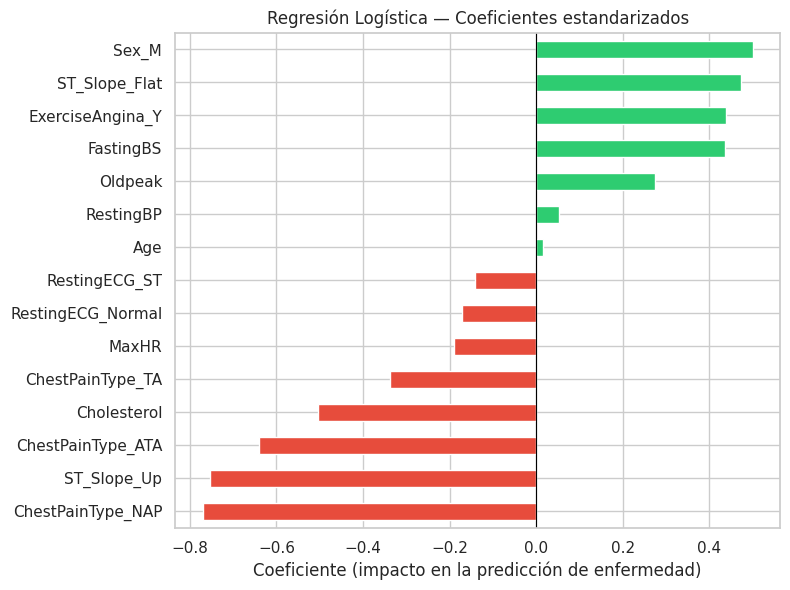


Interpretación: Un coeficiente positivo alto indica que valores mayores
de esa característica incrementan la probabilidad de clasificar como "Enfermedad (1)".


In [70]:
# 5.2 Coeficientes del modelo (interpretabilidad)
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=X_train.columns
).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs.values]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Regresión Logística — Coeficientes estandarizados')
ax.set_xlabel('Coeficiente (impacto en la predicción de enfermedad)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nInterpretación: Un coeficiente positivo alto indica que valores mayores')
print('de esa característica incrementan la probabilidad de clasificar como "Enfermedad (1)".')

## 6. Modelo 2 — Árbol de Decisión


In [71]:
# 6.1 Pipeline (los árboles de decisión no requieren estandarización)
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

scores_dt = cross_val_score(pipe_dt, X_train, y_train, cv=cv, scoring='f1')
print(f'Decision Tree — F1 CV: {scores_dt.mean():.4f} ± {scores_dt.std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Decision Tree — F1 CV: 0.8504 ± 0.0222


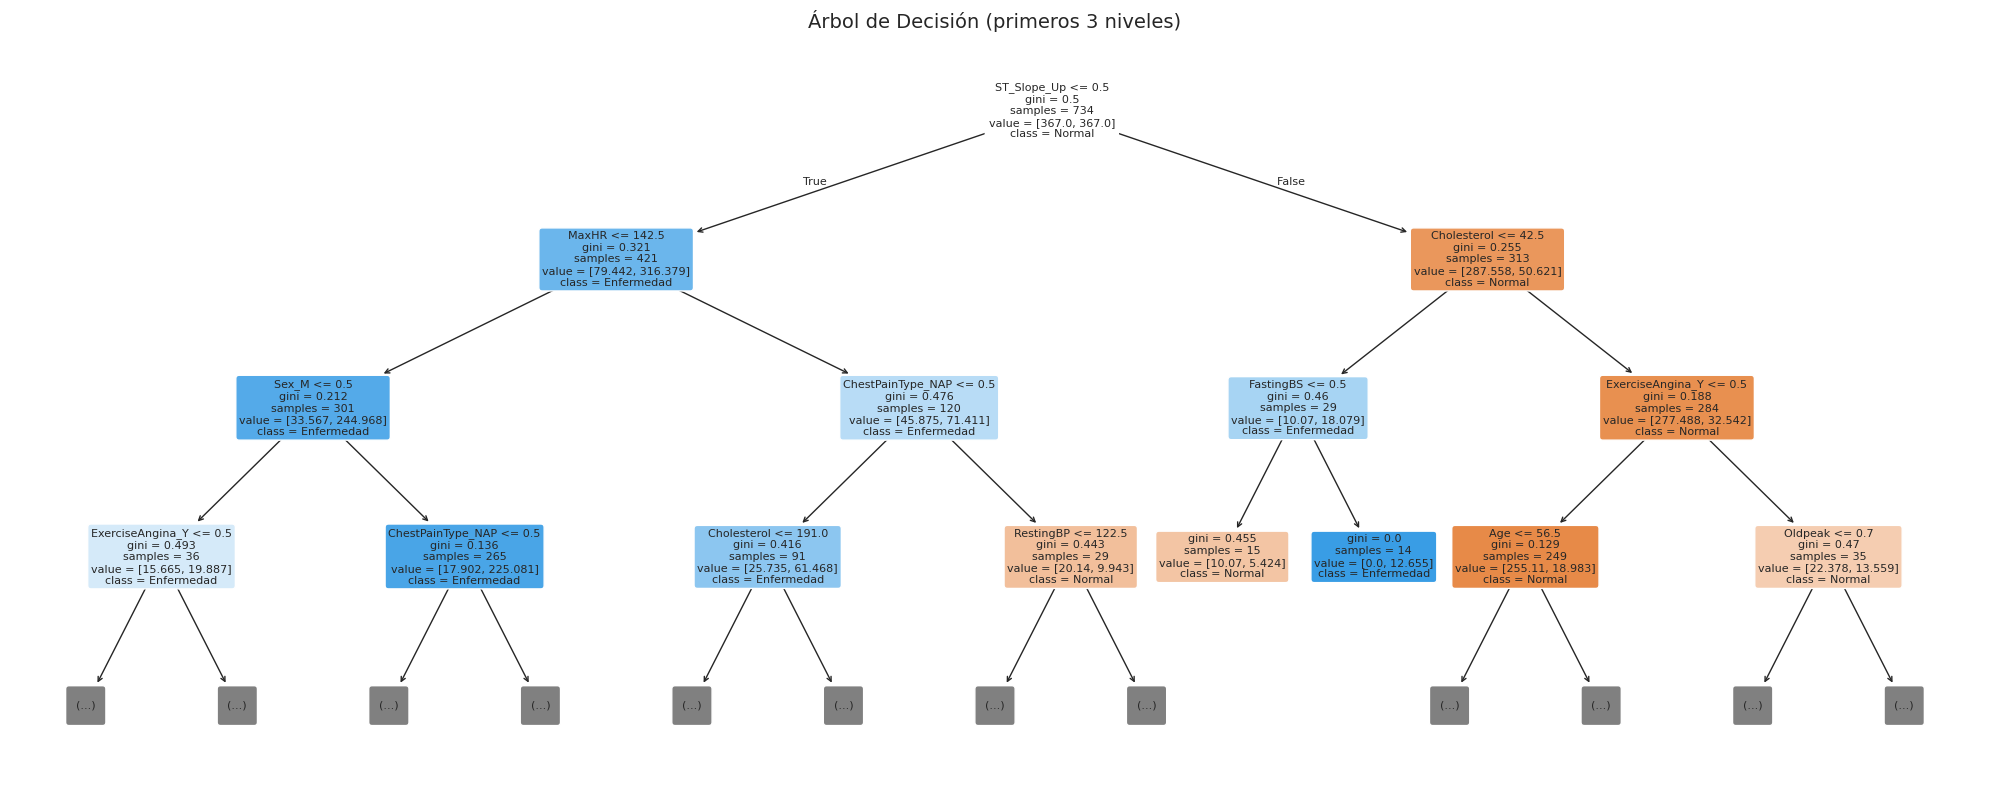

In [72]:
# 6.2 Visualización del árbol
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    pipe_dt.named_steps['clf'],
    feature_names=list(X_train.columns),
    class_names=['Normal', 'Enfermedad'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    max_depth=3  # Mostrar solo 3 niveles para legibilidad
)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

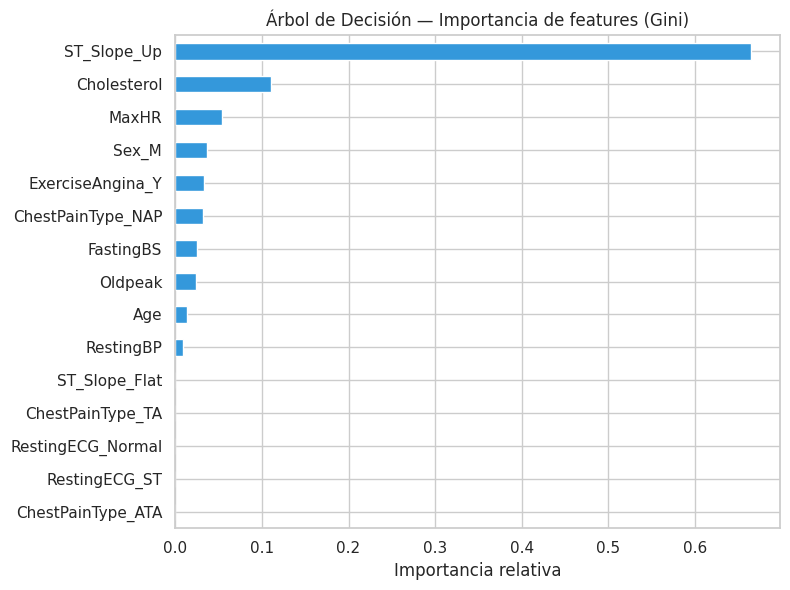

In [73]:
# 6.3 Importancia de features (Gini importance)
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia de features (Gini)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

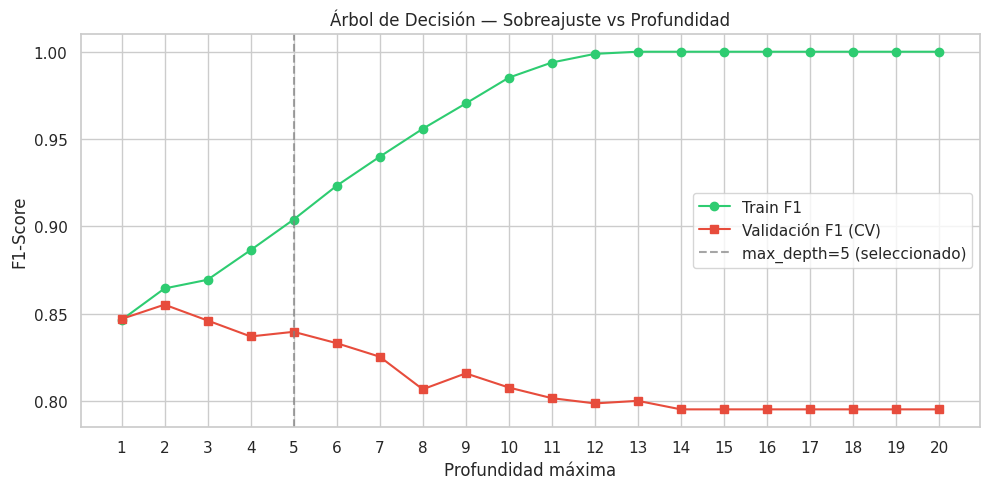

Observación: cuando la brecha entre train y validación crece,
el modelo está sobreajustando (memorizando el train set).


In [74]:
# 6.4 Efecto de la profundidad en sobreajuste/subajuste
depths = range(1, 21)
train_scores = []
val_scores = []

for d in depths:
    dt = DecisionTreeClassifier(
        max_depth=d, class_weight='balanced',
        random_state=RANDOM_STATE
    )
    dt.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, dt.predict(X_train)))
    cv_s = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1')
    val_scores.append(cv_s.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths, val_scores, 's-', label='Validación F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1-Score')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad')
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.show()

print('Observación: cuando la brecha entre train y validación crece,')
print('el modelo está sobreajustando (memorizando el train set).')

## 7. Modelo 3 — Support Vector Machine (SVM)

In [75]:
# 7.1 Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced',
                    random_state=RANDOM_STATE, probability=True))
    ])
    scores = cross_val_score(pipe_svm, X_train, y_train, cv=cv, scoring='f1')
    svm_results[kernel] = scores
    print(f'SVM ({kernel:6s}) — F1 CV: {scores.mean():.4f} ± {scores.std():.4f}')

# Seleccionar el mejor kernel automáticamente
best_kernel = max(svm_results, key=lambda k: svm_results[k].mean())
print(f'\nMejor kernel: {best_kernel}')

SVM (linear) — F1 CV: 0.8619 ± 0.0309
SVM (rbf   ) — F1 CV: 0.8813 ± 0.0275
SVM (poly  ) — F1 CV: 0.8567 ± 0.0285

Mejor kernel: rbf


In [76]:
# 7.2 Entrenamiento con el mejor kernel
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced',
                random_state=RANDOM_STATE, probability=True))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
scores_svm = svm_results[best_kernel]

In [77]:
# 7.3 Impacto de la estandarización en SVM
svm_no_scale = SVC(kernel=best_kernel, class_weight='balanced',
                    random_state=RANDOM_STATE)
scores_no_scale = cross_val_score(svm_no_scale, X_train, y_train, cv=cv, scoring='f1')

print('\nImpacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 = {scores_svm.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_no_scale.mean():.4f}')
diff = (scores_svm.mean() - scores_no_scale.mean()) * 100
print(f'  Diferencia: {diff:+.2f} puntos porcentuales')
print('\n→ La estandarización es CRÍTICA para modelos basados en distancias.')


Impacto de la estandarización en SVM:
  CON StandardScaler: F1 = 0.8813
  SIN StandardScaler: F1 = 0.7109
  Diferencia: +17.04 puntos porcentuales

→ La estandarización es CRÍTICA para modelos basados en distancias.


## 8. Modelo 4 — K-Nearest Neighbors (KNN)

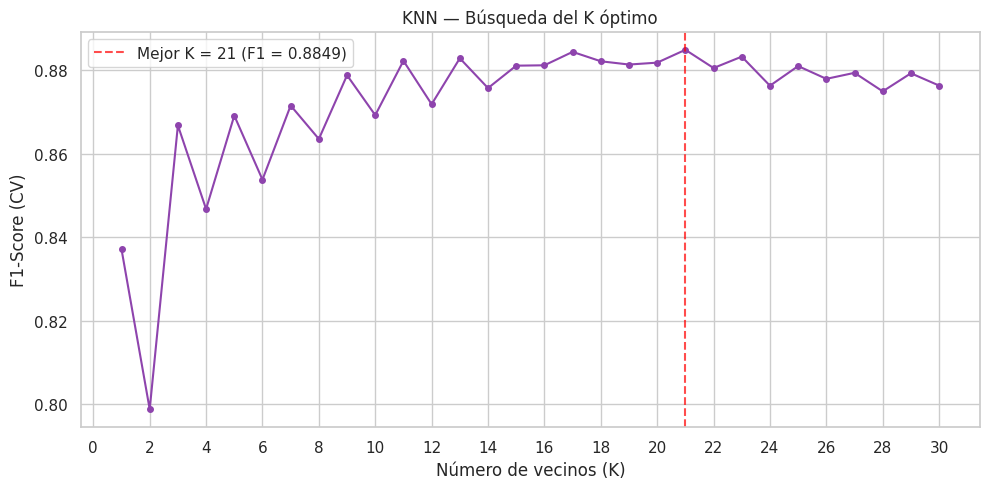

K óptimo seleccionado: 21


In [78]:
# 8.1 Búsqueda del K óptimo
k_range = range(1, 31)
k_scores = []

for k in k_range:
    pipe_knn = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k} (F1 = {max(k_scores):.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN — Búsqueda del K óptimo')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'K óptimo seleccionado: {best_k}')

In [79]:
# 8.2 Entrenamiento con K óptimo
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])

scores_knn = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
print(f'KNN (K={best_k}) — F1 CV: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=21) — F1 CV: 0.8849 ± 0.0277


## 9. Análisis comparativo de modelos

In [80]:
# 9.1 Tabla resumen
models = {
    'Logistic Regression': (pipe_lr, y_pred_lr, scores_lr),
    'Decision Tree':       (pipe_dt, y_pred_dt, scores_dt),
    f'SVM ({best_kernel})': (pipe_svm, y_pred_svm, scores_svm),
    f'KNN (K={best_k})':   (pipe_knn, y_pred_knn, scores_knn)
}

summary = []
for name, (pipe, y_pred, cv_scores) in models.items():
    summary.append({
        'Modelo': name,
        'F1 CV (mean)': f'{cv_scores.mean():.4f}',
        'F1 CV (std)': f'{cv_scores.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test, y_pred):.4f}'
    })

summary_df = pd.DataFrame(summary)
print('='*80)
print('COMPARACIÓN DE MODELOS — HEART FAILURE PREDICTION')
print('='*80)
display(summary_df)

COMPARACIÓN DE MODELOS — HEART FAILURE PREDICTION


,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test
0,Logistic Regression,0.8559,0.0304,0.8913,0.9048
1,Decision Tree,0.8504,0.0222,0.8315,0.8410
2,SVM (rbf),0.8813,0.0275,0.8859,0.8986
3,KNN (K=21),0.8849,0.0277,0.9022,0.9135


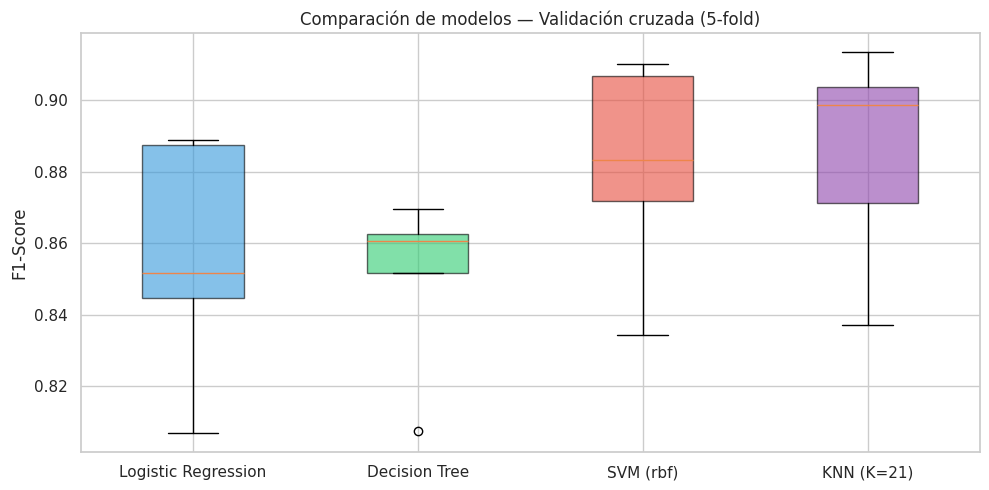

In [81]:
# 9.2 Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [scores_lr, scores_dt, scores_svm, scores_knn]
labels = list(models.keys())
bp = ax.boxplot(cv_data, tick_labels=labels, patch_artist=True)
colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']

for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('F1-Score')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold)')
plt.tight_layout()
plt.show()

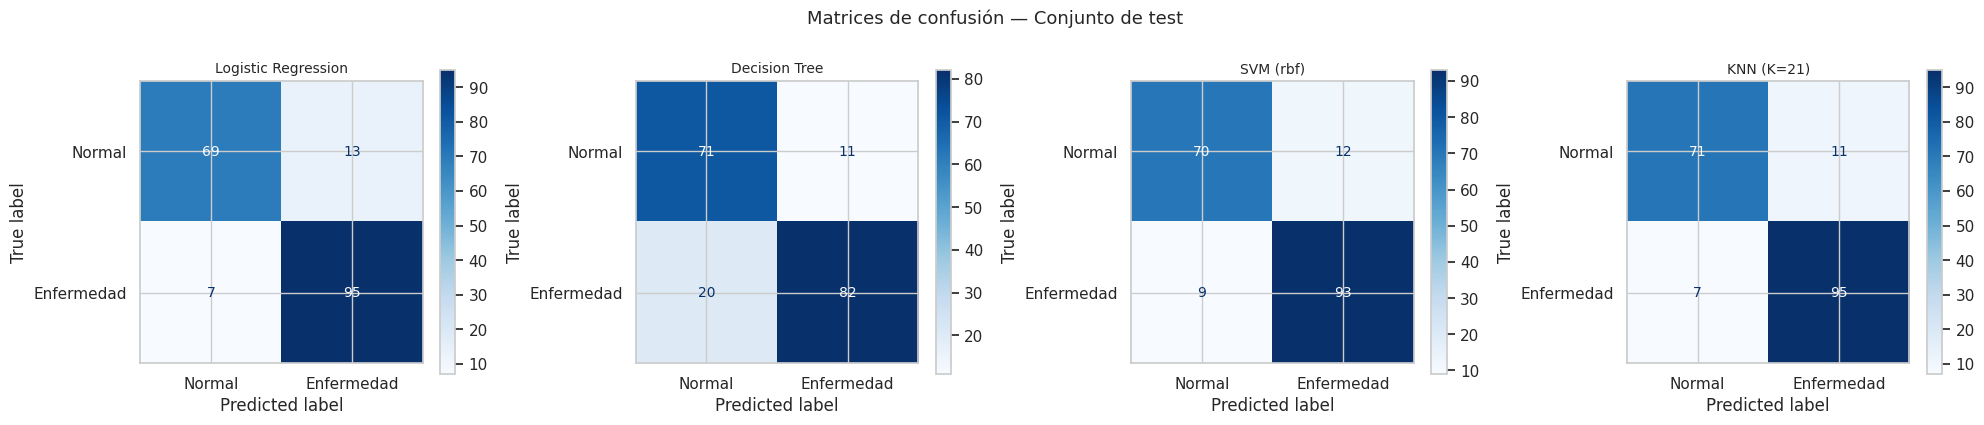

In [82]:
# 9.3 Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (pipe, y_pred, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Normal', 'Enfermedad'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusión — Conjunto de test', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

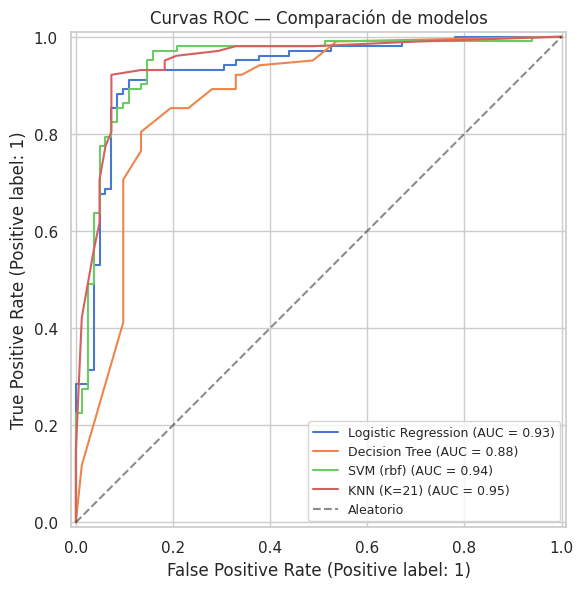

In [83]:
# 9.4 Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))

for name, (pipe, _, _) in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [84]:
# 9.5 Classification report detallado del mejor modelo
best_model_name = max(models, key=lambda k: float(models[k][2].mean()))
best_pipe, best_pred, best_cv = models[best_model_name]

print(f'\nMejor modelo seleccionado: {best_model_name}')
print('='*60)
print(classification_report(y_test, best_pred,
                            target_names=['Normal', 'Enfermedad']))


Mejor modelo seleccionado: KNN (K=21)
              precision    recall  f1-score   support

      Normal       0.91      0.87      0.89        82
  Enfermedad       0.90      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



# 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
| :--- | :--- | :--- | :--- |
| **Regresión Logística** | Rápido, interpretable (coeficientes), probabilístico | Asume relación lineal entre features y log-odds | Baseline; cuando la interpretabilidad es prioritaria |
| **Árbol de Decisión** | Interpretable (visualización), maneja no linealidades, no requiere estandarización | Propenso a sobreajuste; inestable (pequeños cambios en datos alteran el árbol) | Cuando se necesitan reglas explicables; como parte de ensambles|
| **SVM** | Efectivo en alta dimensionalidad; flexible con kernels | Sensible a la escala; costoso en datasets grandes; difícil de interpretar | Datasets de tamaño moderado con fronteras complejas |
| **KNN** | Simple, no paramétrico, adaptable | Lento en predicción (distancias contra todo el train); sensible a escala y dimensionalidad | Datasets pequeños-medianos; cuando la frontera es irregular |

# 11. Conclusiones del Proyecto

**1. Desempeño General de los Modelos**
El análisis comparativo sobre el dataset de *Heart Failure Prediction* demostró que los modelos basados en márgenes y fronteras continuas (como SVM y Regresión Logística) alcanzaron un rendimiento superior y más estable en términos de **F1-Score** y **Accuracy** en comparación con los modelos basados en divisiones ortogonales (Árboles de Decisión).

**2. Importancia Crucial del Preprocesamiento**
La estandarización mediante `StandardScaler` resultó ser indispensable para algoritmos sensibles a la escala y distancias como **SVM** y **KNN**. Omitir este paso genera una caída drástica en las métricas de rendimiento, ya que variables con mayor rango (como *Cholesterol* o *RestingBP*) opacan indebidamente a variables de menor rango pero altamente predictivas (como *Oldpeak* o *FastingBS*).

**3. Hallazgos Clínicos e Interpretabilidad**
A través de los coeficientes de la Regresión Logística y la importancia de características del Árbol de Decisión, se identificó que las variables con mayor peso en el diagnóstico de enfermedad cardíaca son la pendiente del segmento ST (*ST_Slope*), la angina inducida por ejercicio (*ExerciseAngina*), la depresión del segmento ST (*Oldpeak*) y la frecuencia cardíaca máxima (*MaxHR*). Esto valida que los modelos aprendieron relaciones biomédicas reales y coherentes.

**4. Criterio de Selección en el Ámbito Médico**
En problemas de diagnóstico de salud, la prioridad clínica radica en minimizar los **Falsos Negativos** (casos en los que un paciente enfermo es clasificado erróneamente como normal). Por ello, además del F1-Score global, la elección del modelo final en producción debe favorecer a aquel que presente la mayor **Sensibilidad (Recall)** y un área bajo la curva **ROC (AUC)** más elevada.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*